# Linear Regression Plots

**Linear Regression Plots** check whether a linear relationship is stable across levels of a grouping variable. Four separate plots are computed, each showing one aspect of a simple linear fit (y ~ x) per group:

| Plot | Shows | Good pattern |
|---|---|---|
| **Linear Correlation Plot** | Pearson r per group | All r values near a constant |
| **Linear Intercept Plot** | Fitted intercept (a) per group | Constant a across groups |
| **Linear Slope Plot** | Fitted slope (b) per group | Constant b across groups |
| **Linear Residual SD Plot** | Residual standard deviation per group | Constant σ across groups |

Together they answer: *Is the underlying linear model the same across all groups?*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

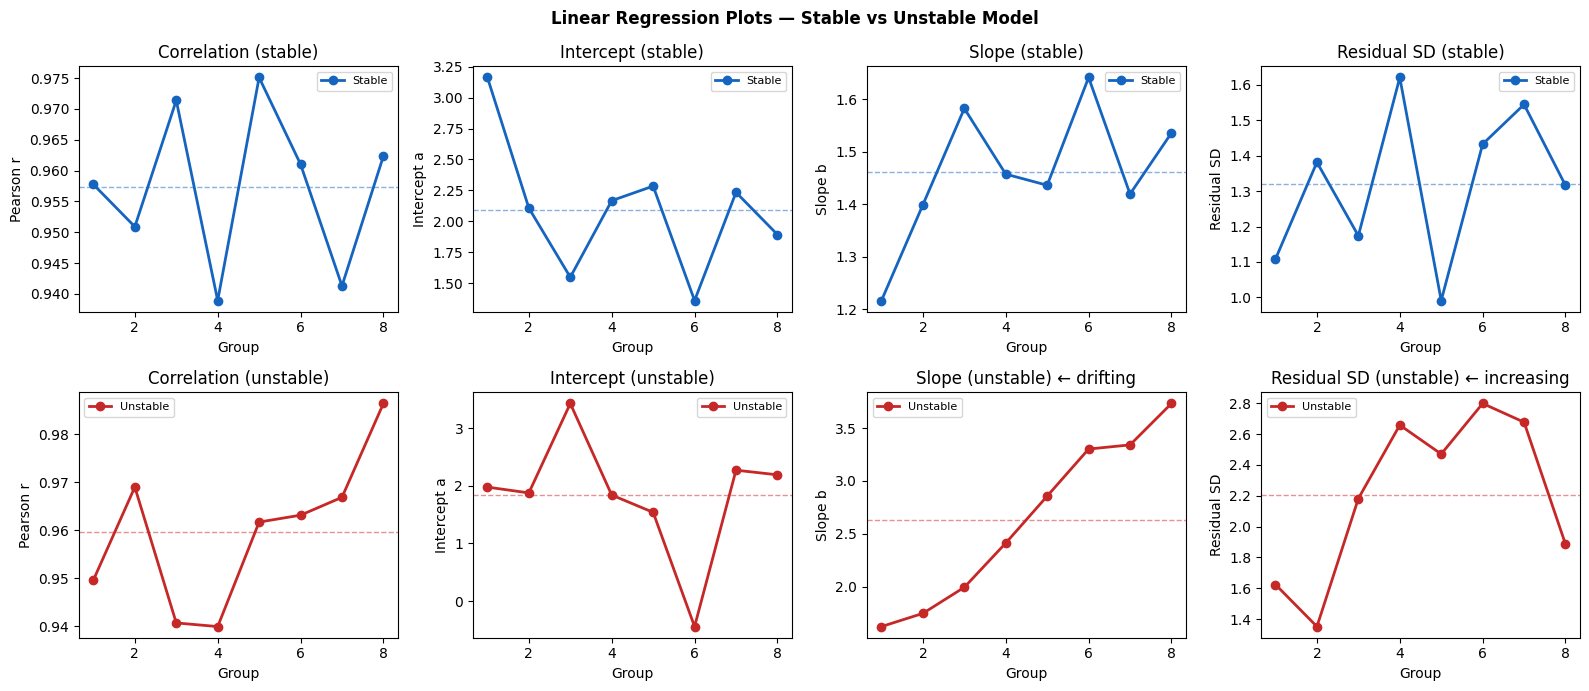

Stable model — CV of each statistic:
  r           : mean=0.957, CV=1.3%
  intercept   : mean=2.095, CV=24.3%
  slope       : mean=1.461, CV=8.3%
  resid_sd    : mean=1.321, CV=15.4%


In [2]:
np.random.seed(42)
n_groups = 8
n_per_group = 20
x_base = np.linspace(0, 10, n_per_group)

# Stable model: same slope, intercept, variance across groups
def fit_group(x, y):
    slope, intercept, r, _, _ = stats.linregress(x, y)
    residuals = y - (slope * x + intercept)
    return r, intercept, slope, residuals.std()

groups = np.arange(1, n_groups + 1)

# Stable case
rs_s, ints_s, slps_s, sds_s = [], [], [], []
for g in groups:
    y = 2 + 1.5 * x_base + np.random.normal(0, 1.5, n_per_group)
    r, a, b, s = fit_group(x_base, y)
    rs_s.append(r); ints_s.append(a); slps_s.append(b); sds_s.append(s)

# Unstable case: slope drifts
rs_u, ints_u, slps_u, sds_u = [], [], [], []
for g in groups:
    slope_g = 1.5 + 0.3 * (g - 1)
    y = 2 + slope_g * x_base + np.random.normal(0, 1.5 + 0.2*g, n_per_group)
    r, a, b, s = fit_group(x_base, y)
    rs_u.append(r); ints_u.append(a); slps_u.append(b); sds_u.append(s)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Linear Regression Plots — Stable vs Unstable Model', fontsize=12, fontweight='bold')

def plot_stat(ax, groups, vals_s, vals_u, ylabel, title):
    ax.plot(groups, vals_s, 'o-', color='#1565C0', lw=2, ms=6, label='Stable')
    ax.axhline(np.mean(vals_s), color='#1565C0', lw=1, ls='--', alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Group'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

def plot_stat2(ax, groups, vals_u, ylabel, title):
    ax.plot(groups, vals_u, 'o-', color='#C62828', lw=2, ms=6, label='Unstable')
    ax.axhline(np.mean(vals_u), color='#C62828', lw=1, ls='--', alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Group'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plot_stat(axes[0,0], groups, rs_s, None, 'Pearson r', 'Correlation (stable)')
plot_stat(axes[0,1], groups, ints_s, None, 'Intercept a', 'Intercept (stable)')
plot_stat(axes[0,2], groups, slps_s, None, 'Slope b', 'Slope (stable)')
plot_stat(axes[0,3], groups, sds_s, None, 'Residual SD', 'Residual SD (stable)')

plot_stat2(axes[1,0], groups, rs_u, 'Pearson r', 'Correlation (unstable)')
plot_stat2(axes[1,1], groups, ints_u, 'Intercept a', 'Intercept (unstable)')
plot_stat2(axes[1,2], groups, slps_u, 'Slope b', 'Slope (unstable) ← drifting')
plot_stat2(axes[1,3], groups, sds_u, 'Residual SD', 'Residual SD (unstable) ← increasing')

plt.tight_layout(); plt.show()

print('Stable model — CV of each statistic:')
for name, vals in [('r', rs_s), ('intercept', ints_s), ('slope', slps_s), ('resid_sd', sds_s)]:
    cv = np.std(vals) / abs(np.mean(vals)) * 100
    print(f'  {name:12s}: mean={np.mean(vals):.3f}, CV={cv:.1f}%')

## Key Takeaways

| | |
|---|---|
| **All four flat** | Linear model is stable — same relationship across all groups |
| **Slope drifts** | Interaction between group and x — separate regressions needed |
| **Intercept drifts** | Group shift in level — add group as a factor |
| **Residual SD increases** | Heteroscedasticity — variance depends on group |
| **r drops in some groups** | Non-linearity or outliers in specific groups |
| **Use case** | Compare regression fits across labs, time periods, instruments, batches |